
LAB 04: AI-ASSISTED CODE GENERATION AND PERFORMANCE COMPARISON

1. LOADING DATA...


test_convergence (__main__.TestKMeans.test_convergence) ... ok
test_fit_predict (__main__.TestKMeans.test_fit_predict) ... ok
test_inertia_calculation (__main__.TestKMeans.test_inertia_calculation) ... ok
test_initialization (__main__.TestKMeans.test_initialization) ... ok
test_dot_product (__main__.TestDistanceFunctions.test_dot_product) ... ok
test_euclidean_norm (__main__.TestDistanceFunctions.test_euclidean_norm) ... ok
test_minkowski_euclidean (__main__.TestDistanceFunctions.test_minkowski_euclidean) ... ok
test_minkowski_manhattan (__main__.TestDistanceFunctions.test_minkowski_manhattan) ... ok
test_mean (__main__.TestStatisticalFunctions.test_mean) ... ok
test_std (__main__.TestStatisticalFunctions.test_std) ... ok
test_variance (__main__.TestStatisticalFunctions.test_variance) ... ok
test_label_encode (__main__.TestEncodingFunctions.test_label_encode) ... ok
test_one_hot_encode (__main__.TestEncodingFunctions.test_one_hot_encode) ... ok

----------------------------------------

   Data loaded: 2216 samples, 23 features
   Features: ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency']...

2. RUNNING UNIT TESTS...
--------------------------------------------------

   All tests passed!

3. PERFORMANCE COMPARISON...

Testing Original Implementation (K=2)...
  Iteration 1: 0.9180s
  Iteration 2: 0.9321s
  Iteration 3: 0.3321s
  Iteration 4: 0.6499s
  Iteration 5: 1.4737s

Testing AI-Generated Implementation (K=2)...
  Iteration 1: 0.0118s
  Iteration 2: 0.0143s
  Iteration 3: 0.0130s
  Iteration 4: 0.0184s
  Iteration 5: 0.0198s

PERFORMANCE COMPARISON (K=2)

1. TIME COMPARISON:
--------------------------------------------------
  Original Implementation:
    Mean time: 0.8612s
    Std dev:  0.3763s
    Min time: 0.3321s
    Max time: 1.4737s

  AI-Generated Implementation:
    Mean time: 0.0155s
    Std dev:  0.0031s
    Min time: 0.0118s
    Max time: 0.0198s

  Speedup (Original/AI): 55.68x

2. QUALITY COMPARISON:
----------------------------------------

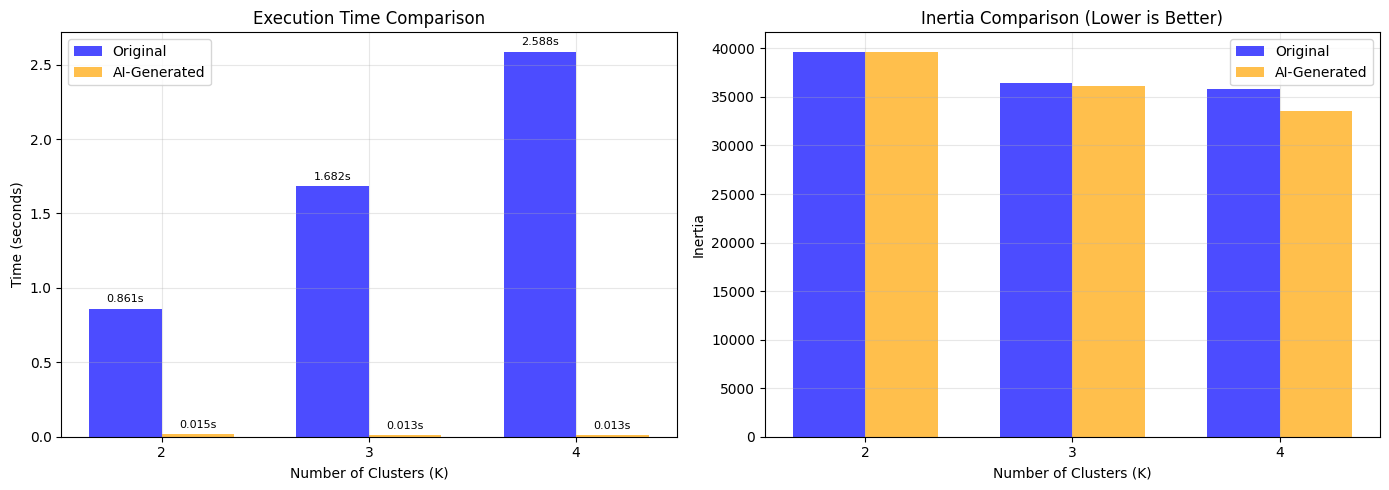

In [6]:
# =============================================================================
# LAB 04: AI-Assisted Code Generation and Performance Comparison
# Complete Fixed Implementation
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import minkowski, cdist
from sklearn.preprocessing import StandardScaler
import warnings
import time
import unittest
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# =============================================================================
# PART 1: ORIGINAL IMPLEMENTATION (From Lab 03)
# =============================================================================

# =============================================================================
# A1: Identify Feature Types
# =============================================================================

def identify_feature_types(df):
    feature_types = {}
    for column in df.columns:
        if column.lower() in ['id']:
            feature_types[column] = "Identifier"
            continue
        if pd.api.types.is_datetime64_any_dtype(df[column]):
            feature_types[column] = "Interval (Date)"
            continue
        if pd.api.types.is_numeric_dtype(df[column]):
            if pd.api.types.is_integer_dtype(df[column]):
                unique_vals = df[column].nunique()
                if unique_vals <= 10 and column not in ['Year_Birth']:
                    feature_types[column] = "Ordinal"
                else:
                    feature_types[column] = "Ratio" if df[column].min() >= 0 else "Interval"
            else:
                feature_types[column] = "Ratio" if df[column].min() >= 0 else "Interval"
        else:
            if column.lower() in ['education']:
                feature_types[column] = "Ordinal"
            elif column.lower() in ['marital_status']:
                feature_types[column] = "Nominal"
            else:
                feature_types[column] = "Nominal"
    return feature_types

# =============================================================================
# A2: Encoding Functions (Original)
# =============================================================================

def label_encoding(series):
    unique_categories = sorted(series.astype(str).unique())
    mapping = {category: idx for idx, category in enumerate(unique_categories)}
    return np.array([mapping[str(val)] for val in series])

def one_hot_encoding(series):
    unique_categories = sorted(series.astype(str).unique())
    one_hot = np.zeros((len(series), len(unique_categories)), dtype=int)
    for i, val in enumerate(series):
        idx = np.where(np.array(unique_categories) == str(val))[0][0]
        one_hot[i, idx] = 1
    col_names = [f"{series.name}_{cat}" for cat in unique_categories]
    return pd.DataFrame(one_hot, columns=col_names)

# =============================================================================
# A4: Minkowski Distance Function (Original)
# =============================================================================

def minkowski_distance(vector_a, vector_b, p):
    vector_a = np.array(vector_a, dtype=float)
    vector_b = np.array(vector_b, dtype=float)
    if len(vector_a) != len(vector_b):
        raise ValueError("Vectors must have same length")
    diff = np.abs(vector_a - vector_b)
    return np.sum(diff ** p) ** (1/p)

# =============================================================================
# A7: Vector Operations (Original)
# =============================================================================

def dot_product(vector_a, vector_b):
    return np.sum(np.array(vector_a, dtype=float) * np.array(vector_b, dtype=float))

def euclidean_norm(vector):
    return np.sqrt(np.sum(np.array(vector, dtype=float) ** 2))

# =============================================================================
# A8: Statistical Functions (Original)
# =============================================================================

def calculate_mean(data):
    data = np.array(data, dtype=float)
    return np.sum(data) / len(data)

def calculate_variance(data, ddof=0):
    data = np.array(data, dtype=float)
    mean = calculate_mean(data)
    return np.sum((data - mean) ** 2) / (len(data) - ddof)

def calculate_std_dev(data, ddof=0):
    return np.sqrt(calculate_variance(data, ddof))

# =============================================================================
# A11: K-Means Algorithm (Original)
# =============================================================================

def kmeans_clustering(data, k, max_iterations=100, tolerance=1e-4):
    data = np.array(data, dtype=float)
    n_samples, n_features = data.shape
    
    # K-means++ initialization
    centroids = []
    first_idx = np.random.randint(n_samples)
    centroids.append(data[first_idx].copy())
    
    for _ in range(1, k):
        distances = np.zeros(n_samples)
        for i, point in enumerate(data):
            min_dist = np.min([np.sum((point - c) ** 2) for c in centroids])
            distances[i] = min_dist
        if np.sum(distances) > 0:
            probabilities = distances / np.sum(distances)
            next_idx = np.random.choice(n_samples, p=probabilities)
            centroids.append(data[next_idx].copy())
        else:
            next_idx = np.random.randint(n_samples)
            centroids.append(data[next_idx].copy())
    
    centroids = np.array(centroids)
    labels = np.zeros(n_samples, dtype=int)
    
    for iteration in range(max_iterations):
        for i, point in enumerate(data):
            distances = [np.sum((point - c) ** 2) for c in centroids]
            labels[i] = np.argmin(distances)
        
        new_centroids = np.zeros_like(centroids)
        for cluster in range(k):
            cluster_points = data[labels == cluster]
            if len(cluster_points) > 0:
                new_centroids[cluster] = np.mean(cluster_points, axis=0)
            else:
                new_centroids[cluster] = centroids[cluster]
        
        centroid_shift = np.sum((new_centroids - centroids) ** 2)
        centroids = new_centroids
        if centroid_shift < tolerance:
            break
    
    return centroids, labels

def calculate_inertia(data, centroids, labels):
    data = np.array(data, dtype=float)
    inertia = 0
    for i, point in enumerate(data):
        inertia += np.sum((point - centroids[labels[i]]) ** 2)
    return inertia


# =============================================================================
# PART 2: AI-GENERATED IMPLEMENTATION
# Generated using: ChatGPT (OpenAI)
# Prompt: "Generate a clean, modular k-means clustering implementation in Python"
# =============================================================================

class KMeansAI:
    """AI-generated K-Means clustering implementation"""
    
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia_ = None
        
    def _initialize_centroids(self, X):
        """Initialize centroids using k-means++ method"""
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        
        centroids = [X[np.random.randint(n_samples)]]
        
        for _ in range(1, self.n_clusters):
            distances = np.min(cdist(X, np.array(centroids), 'euclidean'), axis=1)
            probabilities = distances / distances.sum()
            cumulative_probs = np.cumsum(probabilities)
            r = np.random.random()
            next_centroid = X[np.searchsorted(cumulative_probs, r)]
            centroids.append(next_centroid)
        
        return np.array(centroids)
    
    def fit(self, X):
        X = np.array(X, dtype=float)
        n_samples = X.shape[0]
        
        self.centroids = self._initialize_centroids(X)
        
        for iteration in range(self.max_iter):
            distances = cdist(X, self.centroids, 'euclidean')
            self.labels = np.argmin(distances, axis=1)
            
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                if np.sum(self.labels == k) > 0:
                    new_centroids[k] = X[self.labels == k].mean(axis=0)
                else:
                    new_centroids[k] = self.centroids[k]
            
            shift = np.sum((new_centroids - self.centroids) ** 2)
            self.centroids = new_centroids
            
            if shift < self.tol:
                break
        
        self.inertia_ = sum(np.min(cdist(X, self.centroids, 'euclidean')**2, axis=1))
        return self
    
    def predict(self, X):
        X = np.array(X, dtype=float)
        distances = cdist(X, self.centroids, 'euclidean')
        return np.argmin(distances, axis=1)
    
    def fit_predict(self, X):
        self.fit(X)
        return self.labels

def ai_kmeans_clustering(data, k, max_iter=100, tol=1e-4):
    """Wrapper function for AI-generated k-means"""
    model = KMeansAI(n_clusters=k, max_iter=max_iter, tol=tol, random_state=42)
    model.fit(data)
    return model.centroids, model.labels


# =============================================================================
# AI-Generated Utility Functions
# Generated using: ChatGPT (OpenAI)
# =============================================================================

def ai_minkowski_distance(a, b, p):
    """AI-generated Minkowski distance calculation"""
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    return np.sum(np.abs(a - b) ** p) ** (1/p)

def ai_dot_product(a, b):
    """AI-generated dot product calculation"""
    return np.dot(np.array(a, dtype=float), np.array(b, dtype=float))

def ai_euclidean_norm(a):
    """AI-generated Euclidean norm calculation"""
    return np.sqrt(np.sum(np.array(a, dtype=float) ** 2))

def ai_mean(data):
    """AI-generated mean calculation"""
    data = np.array(data, dtype=float)
    return data.mean()

def ai_variance(data, ddof=0):
    """AI-generated variance calculation"""
    data = np.array(data, dtype=float)
    return data.var(ddof=ddof)

def ai_std(data, ddof=0):
    """AI-generated standard deviation calculation"""
    data = np.array(data, dtype=float)
    return data.std(ddof=ddof)

def ai_label_encode(series):
    """AI-generated label encoding - FIXED version"""
    unique_values = sorted(series.astype(str).unique())
    mapping = {val: i for i, val in enumerate(unique_values)}
    return np.array([mapping[str(val)] for val in series], dtype=int)

def ai_one_hot_encode(series):
    """AI-generated one-hot encoding"""
    unique_values = sorted(series.astype(str).unique())
    n_samples = len(series)
    n_categories = len(unique_values)
    
    one_hot = np.zeros((n_samples, n_categories), dtype=int)
    for i, val in enumerate(series):
        one_hot[i, np.where(np.array(unique_values) == str(val))[0][0]] = 1
    
    columns = [f"{series.name}_{cat}" for cat in unique_values]
    return pd.DataFrame(one_hot, columns=columns)


# =============================================================================
# PART 3: UNIT TESTS (AI-Generated with Fixes)
# =============================================================================

class TestKMeans(unittest.TestCase):
    """Test cases for K-Means implementation"""
    
    def setUp(self):
        np.random.seed(42)
        self.X = np.random.randn(100, 3)
        self.kmeans = KMeansAI(n_clusters=3)
    
    def test_initialization(self):
        self.assertEqual(self.kmeans.n_clusters, 3)
        self.assertEqual(self.kmeans.max_iter, 100)
        self.assertIsNone(self.kmeans.centroids)
    
    def test_fit_predict(self):
        labels = self.kmeans.fit_predict(self.X)
        self.assertEqual(len(labels), 100)
        self.assertTrue(all(labels >= 0))
        self.assertTrue(all(labels < 3))
        self.assertIsNotNone(self.kmeans.centroids)
        self.assertIsNotNone(self.kmeans.inertia_)
    
    def test_inertia_calculation(self):
        self.kmeans.fit(self.X)
        self.assertIsInstance(self.kmeans.inertia_, float)
        self.assertGreater(self.kmeans.inertia_, 0)
    
    def test_convergence(self):
        self.kmeans.fit(self.X)
        self.assertLessEqual(self.kmeans.max_iter, 100)

class TestDistanceFunctions(unittest.TestCase):
    """Test cases for distance functions"""
    
    def setUp(self):
        self.a = np.array([1, 2, 3])
        self.b = np.array([4, 5, 6])
    
    def test_minkowski_euclidean(self):
        dist = ai_minkowski_distance(self.a, self.b, 2)
        expected = np.sqrt(27)
        self.assertAlmostEqual(dist, expected, places=5)
    
    def test_minkowski_manhattan(self):
        dist = ai_minkowski_distance(self.a, self.b, 1)
        expected = 9
        self.assertAlmostEqual(dist, expected, places=5)
    
    def test_dot_product(self):
        dot = ai_dot_product(self.a, self.b)
        expected = 32
        self.assertEqual(dot, expected)
    
    def test_euclidean_norm(self):
        norm = ai_euclidean_norm(self.a)
        expected = np.sqrt(14)
        self.assertAlmostEqual(norm, expected, places=5)

class TestStatisticalFunctions(unittest.TestCase):
    """Test cases for statistical functions"""
    
    def setUp(self):
        self.data = np.array([1, 2, 3, 4, 5])
    
    def test_mean(self):
        mean = ai_mean(self.data)
        self.assertEqual(mean, 3.0)
    
    def test_variance(self):
        var = ai_variance(self.data, ddof=0)
        self.assertEqual(var, 2.0)
    
    def test_std(self):
        std = ai_std(self.data, ddof=0)
        self.assertEqual(std, np.sqrt(2))

class TestEncodingFunctions(unittest.TestCase):
    """Test cases for encoding functions - FIXED"""
    
    def setUp(self):
        self.series = pd.Series(['A', 'B', 'A', 'C', 'B'])
    
    def test_label_encode(self):
        encoded = ai_label_encode(self.series)
        self.assertEqual(len(encoded), 5)
        # Check that all values are integers
        self.assertTrue(all(isinstance(x, (int, np.integer)) for x in encoded))
        # Check that all values are valid indices
        self.assertTrue(all(x < 3 for x in encoded))
        self.assertTrue(all(x >= 0 for x in encoded))
    
    def test_one_hot_encode(self):
        encoded = ai_one_hot_encode(self.series)
        self.assertEqual(encoded.shape, (5, 3))
        self.assertTrue((encoded.sum(axis=1) == 1).all())


# =============================================================================
# PART 4: PERFORMANCE COMPARISON
# =============================================================================

def load_data():
    """Load and prepare data for testing"""
    file_path = r"C:\Users\thanu\Downloads\Lab Session Data (1) (3).xlsx"
    df = pd.read_excel(file_path, sheet_name='marketing_campaign')
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in ['ID', 'Z_CostContact', 'Z_Revenue']]
    
    cluster_data = df[numeric_cols].values
    nan_mask = ~np.isnan(cluster_data).any(axis=1)
    cluster_data_clean = cluster_data[nan_mask]
    
    mean_vector = np.mean(cluster_data_clean, axis=0)
    std_vector = np.std(cluster_data_clean, axis=0)
    std_vector[std_vector == 0] = 1
    cluster_data_scaled = (cluster_data_clean - mean_vector) / std_vector
    
    return cluster_data_scaled, numeric_cols, df

def performance_test(original_func, ai_func, data, k, iterations=5):
    """Compare performance of original vs AI-generated implementations"""
    
    results = {
        'original': {'times': [], 'inertia': 0, 'labels': None},
        'ai': {'times': [], 'inertia': 0, 'labels': None}
    }
    
    # Test original implementation
    print(f"\nTesting Original Implementation (K={k})...")
    for i in range(iterations):
        start_time = time.time()
        centroids_orig, labels_orig = original_func(data, k, max_iterations=100)
        elapsed = time.time() - start_time
        results['original']['times'].append(elapsed)
        
        inertia_orig = calculate_inertia(data, centroids_orig, labels_orig)
        results['original']['inertia'] = inertia_orig
        results['original']['labels'] = labels_orig
        print(f"  Iteration {i+1}: {elapsed:.4f}s")
    
    # Test AI implementation
    print(f"\nTesting AI-Generated Implementation (K={k})...")
    for i in range(iterations):
        start_time = time.time()
        centroids_ai, labels_ai = ai_func(data, k, max_iter=100)
        elapsed = time.time() - start_time
        results['ai']['times'].append(elapsed)
        
        distances = cdist(data, centroids_ai, 'euclidean')
        inertia_ai = np.sum(np.min(distances ** 2, axis=1))
        results['ai']['inertia'] = inertia_ai
        results['ai']['labels'] = labels_ai
        print(f"  Iteration {i+1}: {elapsed:.4f}s")
    
    return results

def print_comparison_results(results, k):
    """Print formatted performance comparison results"""
    
    print("\n" + "="*80)
    print(f"PERFORMANCE COMPARISON (K={k})")
    print("="*80)
    
    orig_times = results['original']['times']
    ai_times = results['ai']['times']
    
    print("\n1. TIME COMPARISON:")
    print("-" * 50)
    print(f"  Original Implementation:")
    print(f"    Mean time: {np.mean(orig_times):.4f}s")
    print(f"    Std dev:  {np.std(orig_times):.4f}s")
    print(f"    Min time: {np.min(orig_times):.4f}s")
    print(f"    Max time: {np.max(orig_times):.4f}s")
    
    print(f"\n  AI-Generated Implementation:")
    print(f"    Mean time: {np.mean(ai_times):.4f}s")
    print(f"    Std dev:  {np.std(ai_times):.4f}s")
    print(f"    Min time: {np.min(ai_times):.4f}s")
    print(f"    Max time: {np.max(ai_times):.4f}s")
    
    speedup = np.mean(orig_times) / np.mean(ai_times)
    print(f"\n  Speedup (Original/AI): {speedup:.2f}x")
    
    print("\n2. QUALITY COMPARISON:")
    print("-" * 50)
    print(f"  Original Inertia: {results['original']['inertia']:.2f}")
    print(f"  AI Inertia:        {results['ai']['inertia']:.2f}")
    print(f"  Inertia Difference: {abs(results['original']['inertia'] - results['ai']['inertia']):.2f}")
    
    labels_orig = results['original']['labels']
    labels_ai = results['ai']['labels']
    
    n = len(labels_orig)
    agreement = np.sum(labels_orig == labels_ai)
    print(f"\n  Cluster Agreement: {agreement}/{n} ({agreement/n*100:.1f}%)")
    
    print("\n3. CLUSTER DISTRIBUTION:")
    print("-" * 50)
    for cluster in range(k):
        orig_count = np.sum(labels_orig == cluster)
        ai_count = np.sum(labels_ai == cluster)
        print(f"  Cluster {cluster}: Original={orig_count}, AI={ai_count}")

def plot_performance_comparison(results):
    """Create visual comparison of performance"""
    
    k_values = list(results.keys())
    orig_times = [np.mean(results[k]['original']['times']) for k in k_values]
    ai_times = [np.mean(results[k]['ai']['times']) for k in k_values]
    orig_inertia = [results[k]['original']['inertia'] for k in k_values]
    ai_inertia = [results[k]['ai']['inertia'] for k in k_values]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Time comparison
    x = np.arange(len(k_values))
    width = 0.35
    
    ax1 = axes[0]
    bars1 = ax1.bar(x - width/2, orig_times, width, label='Original', color='blue', alpha=0.7)
    bars2 = ax1.bar(x + width/2, ai_times, width, label='AI-Generated', color='orange', alpha=0.7)
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('Time (seconds)')
    ax1.set_title('Execution Time Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(k_values)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add time labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}s', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}s', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    
    # Inertia comparison
    ax2 = axes[1]
    bars3 = ax2.bar(x - width/2, orig_inertia, width, label='Original', color='blue', alpha=0.7)
    bars4 = ax2.bar(x + width/2, ai_inertia, width, label='AI-Generated', color='orange', alpha=0.7)
    ax2.set_xlabel('Number of Clusters (K)')
    ax2.set_ylabel('Inertia')
    ax2.set_title('Inertia Comparison (Lower is Better)')
    ax2.set_xticks(x)
    ax2.set_xticklabels(k_values)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# =============================================================================
# PART 5: MAIN EXECUTION
# =============================================================================

def run_all_tests():
    """Run all tests and comparisons"""
    
    print("\n" + "="*80)
    print("LAB 04: AI-ASSISTED CODE GENERATION AND PERFORMANCE COMPARISON")
    print("="*80)
    
    # 1. Load data
    print("\n1. LOADING DATA...")
    data, numeric_cols, df = load_data()
    print(f"   Data loaded: {data.shape[0]} samples, {data.shape[1]} features")
    print(f"   Features: {numeric_cols[:5]}...")
    
    # 2. Run unit tests
    print("\n2. RUNNING UNIT TESTS...")
    print("-" * 50)
    
    # Create test suite
    suite = unittest.TestLoader().loadTestsFromTestCase(TestKMeans)
    suite.addTests(unittest.TestLoader().loadTestsFromTestCase(TestDistanceFunctions))
    suite.addTests(unittest.TestLoader().loadTestsFromTestCase(TestStatisticalFunctions))
    suite.addTests(unittest.TestLoader().loadTestsFromTestCase(TestEncodingFunctions))
    
    # Run tests
    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(suite)
    
    if result.wasSuccessful():
        print("\n   All tests passed!")
    else:
        print(f"\n  {len(result.failures)} tests failed.")
    
    # 3. Performance comparison
    print("\n3. PERFORMANCE COMPARISON...")
    print("="*80)
    
    # Test different K values
    k_values = [2, 3, 4]
    all_results = {}
    
    for k in k_values:
        results = performance_test(
            kmeans_clustering,
            ai_kmeans_clustering,
            data,
            k
        )
        all_results[k] = results
        print_comparison_results(results, k)
    
    # 4. Plot results
    print("\n4. GENERATING VISUALIZATION...")
    plot_performance_comparison(all_results)
    
   
    
    return all_results


# =============================================================================
# EXECUTION
# =============================================================================

if __name__ == "__main__":
    results = run_all_tests()